# Prise en main des TSFMs — Imputation

> **Objectif :** reconstituer la production éolienne pendant des journées d'**écrêtement** (production volontairement effacée sur demande du réseau) pour estimer **ce qui aurait été produit**. On utilise le TSFM **TS-ICL** en **zero-shot** et on le compare à des baselines simples.

**Cas d'usage.** Lorsqu'un parc est écrêté, la production mesurée ne reflète plus le potentiel du vent. Pour chiffrer l'énergie non produite (indemnisation, bilan, suivi de performance), il faut *rejouer* la journée : que se serait-il passé sans écrêtement ?

On simule ce scénario en effaçant des journées entières d'une série de production réelle, puis on compare les reconstructions à la vérité.

| Approche | Information utilisée |
|---|---|
| **Jour d'avant** (baseline) | la production des 24 h précédant l'écrêtement |
| **Ridge sur la vitesse de vent** (baseline) | la vitesse de vent, relation linéaire ajustée sur la fenêtre |
| **Ridge sur la power curve** (baseline) | la courbe de puissance théorique d'une éolienne appliquée à la vitesse de vent, ajustée sur la fenêtre |
| **TS-ICL** | toute la production observée **avant et après** les trous |
| **TS-ICL + covariable** | idem + la vitesse de vent sur toute la fenêtre |

----------

> Contrairement à la prévision, l'imputation dispose du **passé et du futur** autour du trou.

### Au programme
0. [Données](#data)
1. [Scénario d'écrêtement et protocole](#protocol)
2. [Baseline : jour d'avant](#baseline)
3. [Imputation sans covariable](#no-covariate)
4. [Imputation avec la vitesse de vent](#covariates)
5. [Bilan](#results)

## Imports

In [1]:
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import Ridge

from tsicl.pipeline import TSICL

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__}  |  device: {device}")

# Dossier contenant les checkpoints (voir README)
CKPT_DIR = Path("../checkpoints")

# Légendes : plus grandes, encadrées, centrées sous chaque graphique
from matplotlib.transforms import ScaledTranslation
plt.rcParams.update({"legend.fontsize": 14, "legend.frameon": True, "legend.framealpha": 1,
                     "legend.edgecolor": "0.7", "legend.fancybox": False})

def legend_below(ax, handles=None, labels=None, ncol=None, **kwargs):
    # Place la légende sous l'axe, juste en dessous des graduations et du label de l'axe x.
    if handles is None:
        handles, labels = ax.get_legend_handles_labels()
    fig      = ax.figure
    renderer = fig.canvas.get_renderer()
    box      = ax.get_window_extent(renderer)
    gap      = (box.y0 - ax.get_tightbbox(renderer).y0) / fig.dpi + 0.08          # en pouces
    entry    = (max(len(l) for l in labels) * 0.55 * plt.rcParams["legend.fontsize"] + 45) / 72   # largeur d'une entrée (pouces)
    ncol     = ncol or min(len(labels), max(1, int(box.width / fig.dpi / entry)))
    return ax.legend(handles, labels, loc="upper center", ncol=ncol, bbox_to_anchor=(0.5, 0),
                     bbox_transform=ax.transAxes + ScaledTranslation(0, -gap, fig.dpi_scale_trans), **kwargs)

PyTorch 2.9.1  |  device: cpu


<a id="data"></a>

---
## 0. Données

Production éolienne de la région **Hauts-de-France** en 2021, au **pas horaire**, accompagnée de la **vitesse de vent** régionale. Pour l'exercice, on simule un écrêtement même si un écrêtement sur une région entière n'a pas de sens.

Les données sont découpées en **38 fenêtres indépendantes de 28 jours** (672 pas horaires). Chaque fenêtre est un tenseur à deux canaux :
- canal 0 — **production éolienne** (MW) : la cible
- canal 1 — **vitesse de vent** (m/s) : la covariable

> Seules les fenêtres complètes (`ground_truth.pt`) sont utilisées : on crée nous-mêmes les trous en partie 1.

In [2]:
DATA_PATH = Path("../data/eol_hdf_2021.pt")

data = torch.load(DATA_PATH).numpy()      # [N, 2, T]
y    = data[:, 0]                         # production éolienne (MW)   [N, T]
ws   = data[:, 1]                         # vitesse de vent (m/s)      [N, T]

N, T = y.shape
D    = 24                                 # pas par jour (horaire)
n_days = T // D

print(f"{N} fenêtres x {T} pas horaires ({n_days} jours)")
print(f"Production : {y.min():.0f} -> {y.max():.0f} MW  (moyenne {y.mean():.0f} MW)")
print(f"Vent       : {ws.min():.1f} -> {ws.max():.1f} m/s")

38 fenêtres x 672 pas horaires (28 jours)
Production : 18 -> 4892 MW  (moyenne 1310 MW)
Vent       : 1.0 -> 12.8 m/s


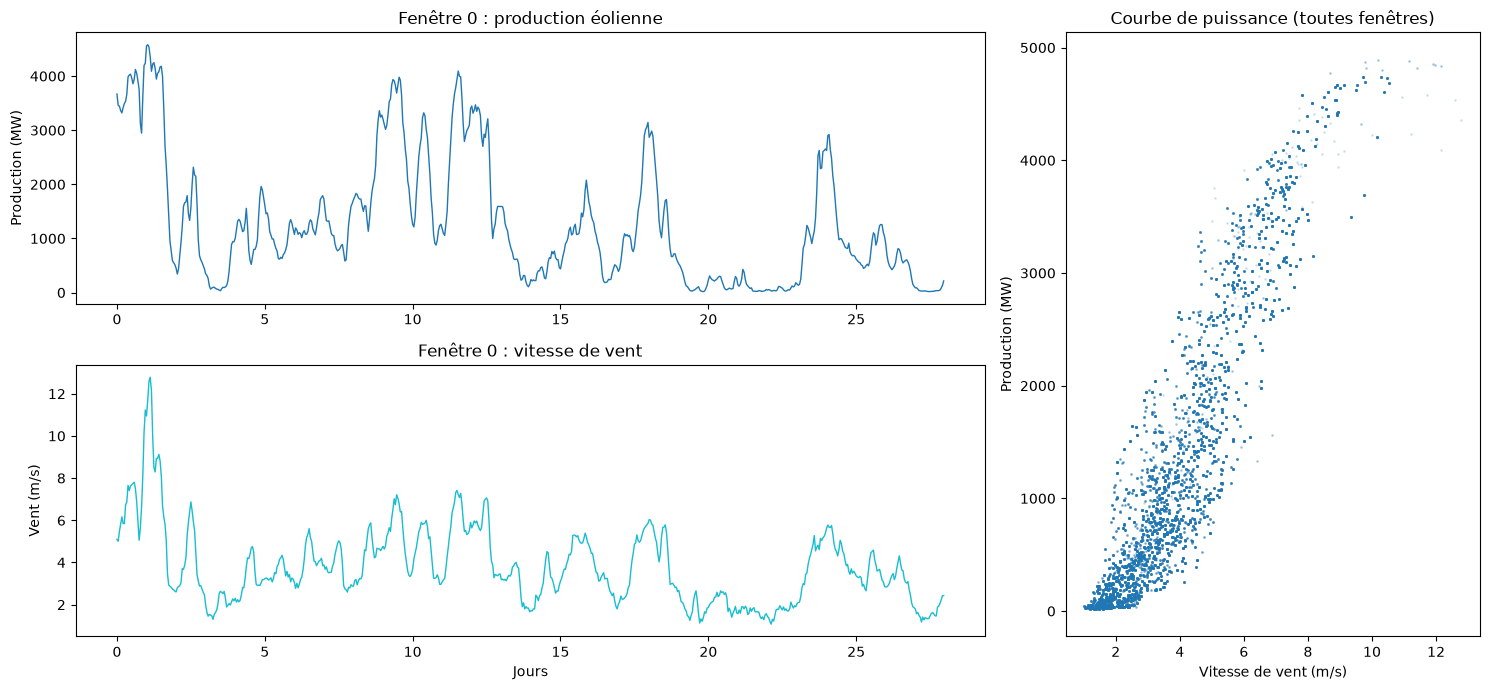

In [3]:
fig = plt.figure(figsize=(15, 7))
gs  = fig.add_gridspec(2, 3)
t_days = np.arange(T) / D

ax = fig.add_subplot(gs[0, :2])
ax.plot(t_days, y[0], color="tab:blue", lw=1)
ax.set_ylabel("Production (MW)")
ax.set_title("Fenêtre 0 : production éolienne")
ax2 = fig.add_subplot(gs[1, :2], sharex=ax)
ax2.plot(t_days, ws[0], color="tab:cyan", lw=1)
ax2.set_ylabel("Vent (m/s)")
ax2.set_xlabel("Jours")
ax2.set_title("Fenêtre 0 : vitesse de vent")

ax = fig.add_subplot(gs[:, 2])
ax.scatter(ws.ravel(), y.ravel(), s=1, alpha=0.15, color="tab:blue")
ax.set_xlabel("Vitesse de vent (m/s)")
ax.set_ylabel("Production (MW)")
ax.set_title("Courbe de puissance (toutes fenêtres)")

plt.tight_layout()
plt.show()

- La production éolienne est **très volatile** et n'a **pas de cycle journalier** marqué : la répéter d'un jour sur l'autre fonctionne mal.
- Elle suit de près la vitesse de vent, mais via une relation **non linéaire** (courbe de puissance en « S » : rien sous ~2 m/s, croissance rapide, puis saturation). Une régression linéaire sur le vent ne capture pas cette forme.

<a id="protocol"></a>

---
## 1. Scénario d'écrêtement et protocole

### 1.1 Création des trous

Dans chaque fenêtre de 28 jours, on efface **2 blocs de 24 h par semaine** (8 journées écrêtées par fenêtre), tirés au hasard avec deux contraintes :
- deux journées écrêtées ne sont **jamais consécutives** (la veille est toujours observée, pour la baseline *jour d'avant*) ;
- la première journée de la fenêtre n'est jamais écrêtée.

La production est mise à `NaN` sur ces blocs. **La vitesse de vent, elle, reste observée partout** : un écrêtement coupe la production, pas le vent.

> Les fenêtres ne commencent pas toutes à minuit : un « jour » désigne ici un bloc de 24 pas consécutifs de la fenêtre.

In [4]:
HOLES_PER_WEEK = 2
rng = np.random.default_rng(0)

def draw_hole_days(n_days, per_week=HOLES_PER_WEEK):
    # Tire `per_week` jours par semaine, ni consécutifs ni en début de fenêtre.
    while True:
        days = np.sort(np.concatenate([rng.choice(np.arange(7 * w, 7 * w + 7), per_week, replace=False)
                                       for w in range(n_days // 7)]))
        if days.min() > 0 and np.all(np.diff(days) > 1):
            return days

hole_days = np.stack([draw_hole_days(n_days) for _ in range(N)])   # [N, n_holes] : indices des jours écrêtés

mask = np.zeros((N, T), dtype=bool)                                # True = production effacée
for i in range(N):
    for d in hole_days[i]:
        mask[i, d * D : (d + 1) * D] = True

y_obs = np.where(mask, np.nan, y)                                  # ce que voient les modèles

print(f"{hole_days.shape[1]} journées écrêtées par fenêtre  |  {mask.sum()} points horaires à reconstituer "
      f"({mask.mean():.0%} de la production)")
print("Jours écrêtés des 3 premières fenêtres :", *hole_days[:3], sep="\n  ")

8 journées écrêtées par fenêtre  |  7296 points horaires à reconstituer (29% de la production)
Jours écrêtés des 3 premières fenêtres :
  [ 4  6  9 12 15 20 22 25]
  [ 1  5  7 12 14 17 24 26]
  [ 4  6 10 13 15 18 25 27]


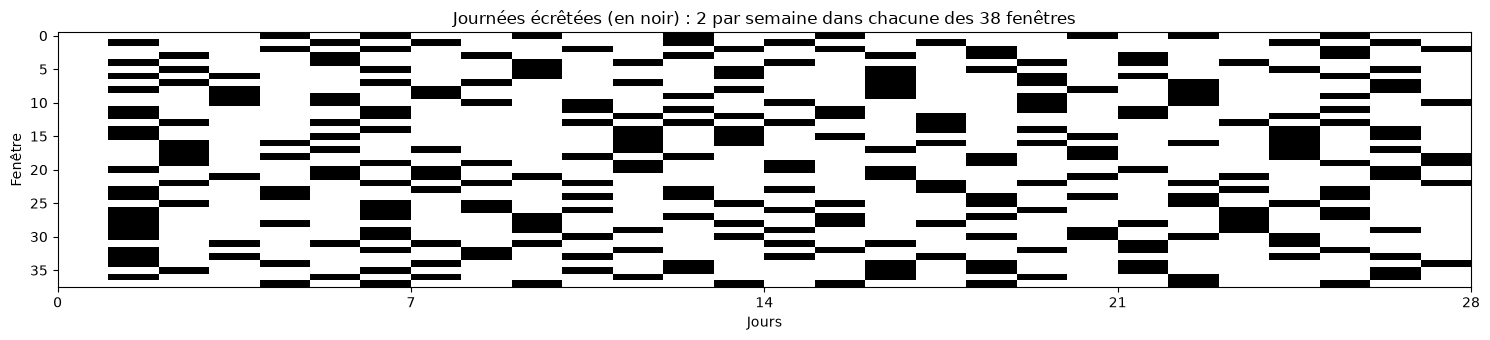

In [5]:
fig, ax = plt.subplots(figsize=(15, 3.5))
ax.imshow(mask, aspect="auto", cmap="Greys", interpolation="nearest", extent=[0, n_days, N - 0.5, -0.5])
ax.set_xlabel("Jours")
ax.set_ylabel("Fenêtre")
ax.set_xticks(np.arange(0, n_days + 1, 7))
ax.set_title("Journées écrêtées (en noir) : 2 par semaine dans chacune des 38 fenêtres")
plt.tight_layout()
plt.show()

### 1.2 Métriques

Toutes les métriques sont calculées **uniquement sur les points effacés** (38 fenêtres × 8 jours × 24 h = 7 296 points par modèle) :
- **MAE (MW)** (↓) et **RMSE (MW)** (↓) — erreur horaire de la reconstruction ponctuelle (médiane pour TS-ICL)
- **MAE norm.** (↓) — MAE après normalisation par fenêtre (moyenne et écart-type calculés sur les seuls points observés), pour comparer des fenêtres calmes et venteuses
- **Erreur énergie (%)** (↓) — la métrique métier : pour chaque journée écrêtée, écart absolu entre l'énergie reconstituée et l'énergie réelle (MWh), rapporté à l'énergie réelle totale
- **WQL** (↓) et **Couverture 80 %** — qualité de la distribution prédictive (TS-ICL est probabiliste), comme dans le notebook forecasting

In [6]:
quantile_levels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
q_idx = {q: i for i, q in enumerate(quantile_levels)}

preds   = {}   # nom -> [N, T] (ponctuel) ou [N, T, Q] (quantiles)
timings = {}   # nom -> temps d'inférence (s)

# Statistiques de normalisation par fenêtre, sur les seuls points observés
mu_obs = np.nanmean(y_obs, axis=1, keepdims=True)
sd_obs = np.nanstd(y_obs, axis=1, keepdims=True)

def median(p):
    return p if p.ndim == 2 else p[..., q_idx[0.5]]

def daily_energy(p):
    # Énergie (MWh) de chaque journée écrêtée : [N, n_holes]
    days = p.reshape(N, n_days, D).sum(-1)
    return np.take_along_axis(days, hole_days, axis=1)

E_true = daily_energy(y)

def wql(p):
    if p.ndim == 2:
        p = np.repeat(p[..., None], len(quantile_levels), axis=-1)
    err = (y[..., None] - p)[mask]                        # [M, Q]
    q   = np.array(quantile_levels)
    pinball = np.maximum(q * err, (q - 1) * err)
    return np.mean(2 * pinball.sum(0) / np.abs(y[mask]).sum())

def coverage_80(p):
    if p.ndim == 2:
        return np.nan
    return np.mean(((y >= p[..., q_idx[0.1]]) & (y <= p[..., q_idx[0.9]]))[mask])

def scores(names=None):
    rows = {}
    for name in names or preds:
        p, m = preds[name], median(preds[name])
        rows[name] = {
            "MAE (MW)":           np.mean(np.abs(y - m)[mask]),
            "RMSE (MW)":          np.sqrt(np.mean(((y - m) ** 2)[mask])),
            "MAE norm.":          np.mean((np.abs(y - m) / sd_obs)[mask]),
            "Erreur énergie (%)": 100 * np.abs(daily_energy(m) - E_true).sum() / E_true.sum(),
            "WQL":                wql(p),
            "Couv. 80 %":         coverage_80(p),
            "Temps (s)":          timings.get(name, np.nan),
        }
    return pd.DataFrame(rows).T

def mae_per_window(name):
    # MAE normalisée de chaque fenêtre : [N]
    err = np.where(mask, np.abs(y - median(preds[name])) / sd_obs, np.nan)
    return np.nanmean(err, axis=1)

In [7]:
COLORS = {"Jour d'avant": "tab:gray", "Ridge (vent)": "tab:orange", "Ridge (power curve)": "goldenrod", "TS-ICL": "tab:red", "TS-ICL + cov": "darkred"}

def plot_window(ax, i, names, days=None, covariate=False, title=None, legend=True):
    # Vérité + reconstructions sur les journées écrêtées (zones grisées) d'une fenêtre.
    days = days or (0, n_days)
    sl   = slice(days[0] * D, days[1] * D)
    t    = np.arange(T)[sl] / D

    ax.plot(t, y_obs[i, sl], color="k", lw=1, label="production observée")
    ax.plot(t, np.where(mask[i], y[i], np.nan)[sl], color="k", lw=1.2, ls="--", label="vérité (effacée)")
    for d in hole_days[i]:
        if days[0] <= d < days[1]:
            ax.axvspan(d, d + 1, color="gray", alpha=0.15, lw=0)
    for name in names:
        p = preds[name][i]
        if p.ndim == 2:
            ax.fill_between(t, np.where(mask[i], p[:, q_idx[0.1]], np.nan)[sl], np.where(mask[i], p[:, q_idx[0.9]], np.nan)[sl],
                            color=COLORS[name], alpha=0.2, lw=0, label=f"{name} (int. 80 %)")
        ax.plot(t, np.where(mask[i], median(preds[name])[i], np.nan)[sl], color=COLORS[name], lw=2, label=name)
    ax.set_ylabel("MW")
    ax.set_title(title or f"Fenêtre {i}")

    handles, labels = ax.get_legend_handles_labels()
    if covariate:
        ax2 = ax.twinx()
        ax2.plot(t, ws[i, sl], color="tab:cyan", lw=0.8, alpha=0.8, label="vent (m/s)")
        ax2.set_ylabel("m/s", color="tab:cyan")
        ax2.tick_params(axis="y", colors="tab:cyan")
        h2, l2 = ax2.get_legend_handles_labels()
        handles, labels = handles + h2, labels + l2
    if legend:
        legend_below(ax, handles, labels)
    return handles, labels

<a id="baseline"></a>

---
## 2. Baseline : jour d'avant

La reconstruction la plus simple : on suppose que la journée écrêtée ressemble à **la veille** : $\hat y_t = y_{t-24}$.

C'est l'équivalent de la baseline *Naive J-1* du notebook forecasting. Par construction, la veille d'une journée écrêtée est toujours observée.

In [8]:
preds["Jour d'avant"] = np.roll(y_obs, D, axis=1)            # décalage de 24 h
assert not np.isnan(preds["Jour d'avant"][mask]).any()       # la veille est toujours observée

scores(["Jour d'avant"]).round(3)

,MAE (MW),RMSE (MW),MAE norm.,Erreur énergie (%),WQL,Couv. 80 %,Temps (s)
Jour d'avant,1066.289,1439.455,0.904,62.715,0.83,NaN,NaN


<a id="no-covariate"></a>

---
## 3. Imputation sans covariable

### 3.1 TS-ICL

TS-ICL reçoit directement la série **avec ses `NaN`** et reconstitue toute la fenêtre. Il exploite la production observée **avant et après** chaque trou, sans aucune information sur le vent.

L'API d'imputation est encore plus simple que celle du forecasting : pas d'horizon ni de contexte à découper, juste la série trouée.

In [9]:
tsicl = TSICL(model_path=CKPT_DIR / "TS-ICL" / "tsicl-v1.ckpt", allow_auto_download=False)

t0 = time.perf_counter()
_, q = tsicl.impute(
    inputs          = y_obs,              # [N, T] avec des NaN sur les journées écrêtées
    batch_size      = 16,
    device          = device,
    quantile_levels = quantile_levels,
    denormalize     = True,               # sortie dans l'échelle d'origine (MW)
)
timings["TS-ICL"] = time.perf_counter() - t0

preds["TS-ICL"] = q.cpu().numpy()         # [N, T, Q] : toute la fenêtre est reconstruite
print(f"TS-ICL : {preds['TS-ICL'].shape}  ({timings['TS-ICL']:.1f} s)")

TS-ICL : (38, 672, 9)  (6.3 s)


### 3.2 Visualisation

Deux semaines d'une fenêtre : les zones grisées sont les journées écrêtées.

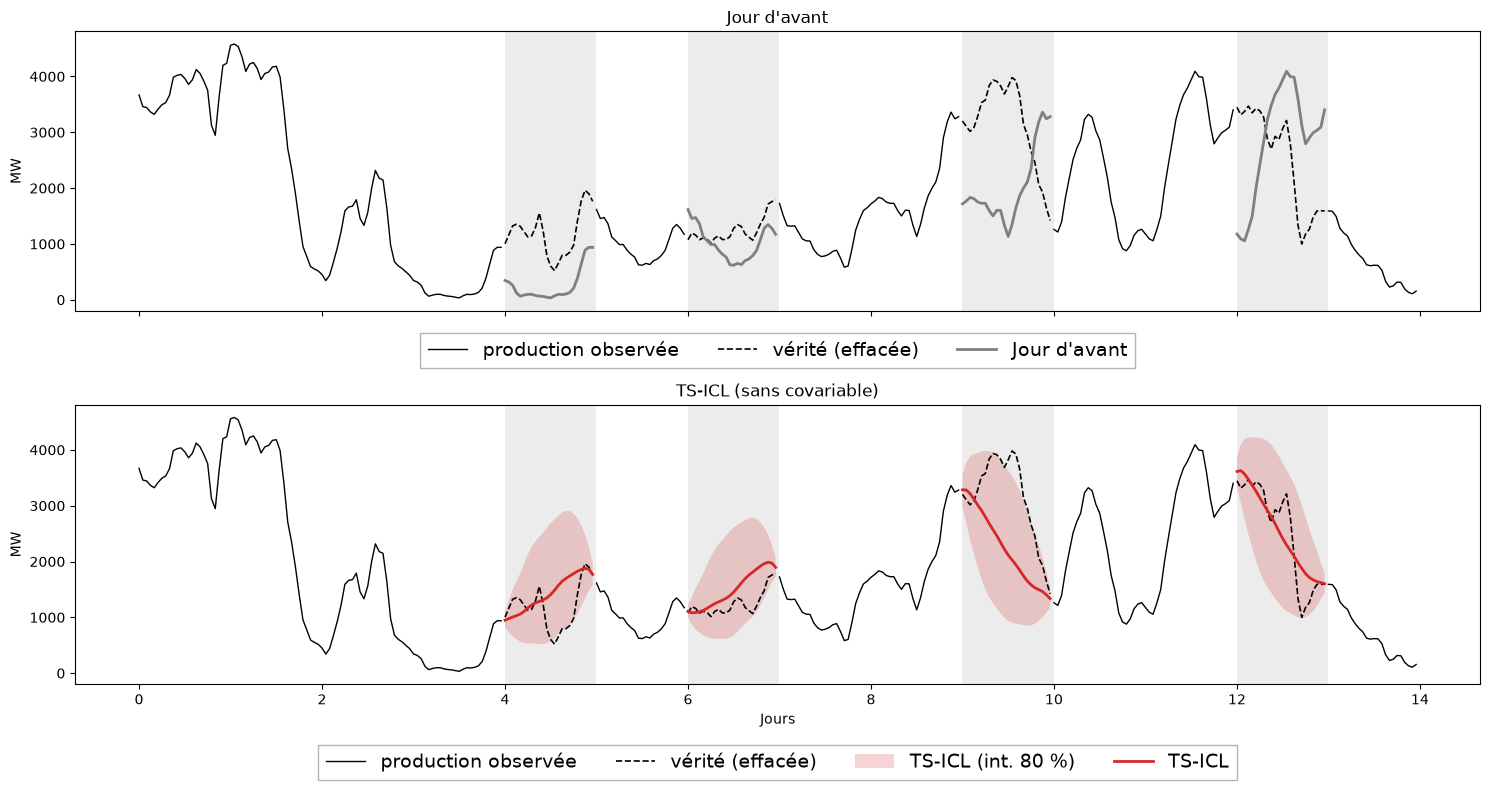

In [10]:
WINDOW, DAYS = 0, (0, 14)

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True, sharey=True)
axes[1].set_xlabel("Jours")
plot_window(axes[0], WINDOW, ["Jour d'avant"], DAYS, title="Jour d'avant")
plot_window(axes[1], WINDOW, ["TS-ICL"], DAYS, title="TS-ICL (sans covariable)")
plt.tight_layout()
plt.show()

### 3.3 Résultats

In [11]:
scores(["Jour d'avant", "TS-ICL"]).round(3).style.highlight_min(subset=["MAE (MW)", "RMSE (MW)", "MAE norm.", "Erreur énergie (%)", "WQL"], color="#5727F5").format(precision=3)

,MAE (MW),RMSE (MW),MAE norm.,Erreur énergie (%),WQL,Couv. 80 %,Temps (s)
Jour d'avant,1066.289,1439.455,0.904,62.715,0.830,nan,nan
TS-ICL,440.927,697.073,0.369,28.265,0.263,0.800,6.293


#### Ce qu'on observe

- Le **jour d'avant** est une très mauvaise reconstruction pour l'éolien : le vent change d'un jour à l'autre, la veille n'a souvent rien à voir avec la journée écrêtée.
- **TS-ICL** divise l'erreur par plus de 2 sans aucune covariable : il raccorde la journée manquante à ce qui se passe **avant et après**, ce qu'une baseline tournée vers le passé ne peut pas faire.
- En revanche, au milieu d'une journée de 24 h, sans information sur le vent, TS-ICL ne peut pas deviner un coup de vent ou une accalmie : sa reconstruction est lissée et son intervalle s'élargit.

<a id="covariates"></a>

---
## 4. Imputation avec la vitesse de vent

La vitesse de vent est observée **même pendant l'écrêtement** : c'est l'information qui permet de rejouer la journée.

### 4.1 Baselines : Ridge sur la vitesse de vent

Pour chaque fenêtre, on ajuste une régression Ridge **production ~ vitesse de vent** sur les points observés, puis on l'applique aux journées écrêtées. Un modèle par fenêtre, sans données d'entraînement externes.

On teste deux variables explicatives :
- **Ridge (vent)** — la vitesse de vent $v$ telle quelle ;
- **Ridge (power curve)** — la **courbe de puissance théorique** d'une éolienne, normalisée entre 0 et 1 :

$$PC(v) = \begin{cases} 0 & v < v_{in} \\ \dfrac{v^3 - v_{in}^3}{v_r^3 - v_{in}^3} & v_{in} \le v < v_r \\ 1 & v \ge v_r \end{cases}$$

  avec $v_{in}$ la vitesse de démarrage et $v_r$ la vitesse nominale (à partir de laquelle la puissance plafonne). La vitesse de vent est ici une **moyenne régionale**, pas le vent au moyeu d'une machine : les valeurs usuelles d'une éolienne ($v_{in} \approx 3$ m/s, $v_r \approx 12$ m/s) ne conviennent pas. On choisit donc $(v_{in}, v_r)$ **par fenêtre**, par recherche sur grille, en minimisant l'erreur sur les points observés.

In [12]:
def fit_ridge(x, i):
    # Ridge production ~ x, ajustée sur les points observés de la fenêtre i. Renvoie (prédiction sur toute la fenêtre, MAE sur les points observés).
    obs   = ~mask[i]
    model = Ridge(alpha=1.0).fit(x[obs, None], y[i, obs])
    pred  = model.predict(x[:, None])
    return pred, np.mean(np.abs(pred - y[i])[obs])

def power_curve(v, v_in, v_r):
    # Courbe de puissance théorique normalisée : 0 sous v_in, montée en v^3, plateau à 1 au-delà de v_r.
    return np.clip((v ** 3 - v_in ** 3) / (v_r ** 3 - v_in ** 3), 0, 1)

# Ridge sur la vitesse de vent
t0 = time.perf_counter()
preds["Ridge (vent)"]   = np.stack([fit_ridge(ws[i], i)[0] for i in range(N)])
timings["Ridge (vent)"] = time.perf_counter() - t0

# Ridge sur la power curve : (v_in, v_r) choisis par fenêtre sur les points observés
GRID = [(v_in, v_r) for v_in in np.arange(0.5, 4.01, 0.25) for v_r in np.arange(4, 12.01, 0.5) if v_r > v_in + 1]

t0 = time.perf_counter()
pc_preds, pc_params = [], []
for i in range(N):
    fits = [fit_ridge(power_curve(ws[i], v_in, v_r), i) for v_in, v_r in GRID]
    best = int(np.argmin([mae for _, mae in fits]))
    pc_preds.append(fits[best][0])
    pc_params.append(GRID[best])
preds["Ridge (power curve)"]   = np.stack(pc_preds)
timings["Ridge (power curve)"] = time.perf_counter() - t0

v_in_med, v_r_med = np.median(pc_params, axis=0)
print(f"Power curve : v_in médian = {v_in_med:.2f} m/s, v_r médian = {v_r_med:.2f} m/s  ({timings['Ridge (power curve)']:.1f} s)")

Power curve : v_in médian = 1.25 m/s, v_r médian = 6.50 m/s  (2.9 s)


### 4.2 TS-ICL + covariable

On passe la vitesse de vent dans `covars`, sur **toute la fenêtre** (y compris les journées écrêtées) : `[N, T, K]` avec `K = 1`. Aucun ajustement : TS-ICL apprend **en contexte** la relation vent → production à partir des points observés de la fenêtre.

In [13]:
t0 = time.perf_counter()
_, q = tsicl.impute(
    inputs          = y_obs,              # [N, T] avec des NaN
    covars          = ws[..., None],      # [N, T, 1] : vitesse de vent, complète
    batch_size      = 16,
    device          = device,
    quantile_levels = quantile_levels,
    denormalize     = True,
)
timings["TS-ICL + cov"] = time.perf_counter() - t0
preds["TS-ICL + cov"]   = q.cpu().numpy()
print(f"TS-ICL + cov : {preds['TS-ICL + cov'].shape}  ({timings['TS-ICL + cov']:.1f} s)")

TS-ICL + cov : (38, 672, 9)  (7.6 s)


### 4.3 Visualisation : on rejoue les journées écrêtées

Vitesse de vent en cyan (axe de droite).

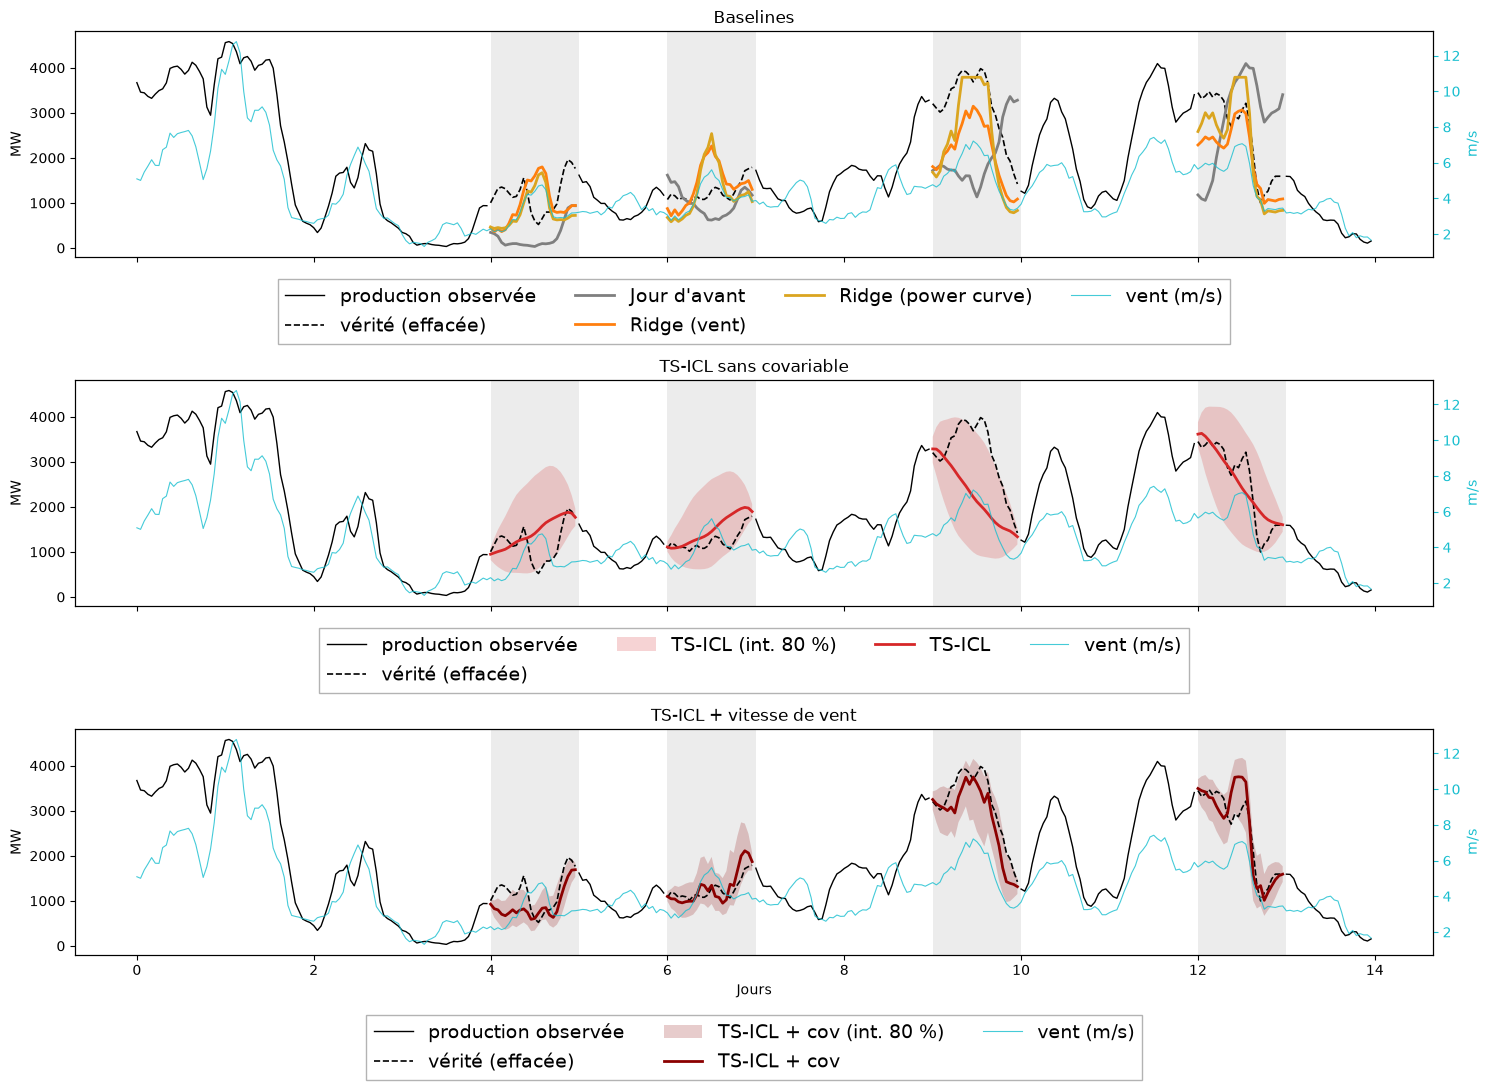

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True, sharey=True)
axes[2].set_xlabel("Jours")
plot_window(axes[0], WINDOW, ["Jour d'avant", "Ridge (vent)", "Ridge (power curve)"], DAYS, covariate=True, title="Baselines")
plot_window(axes[1], WINDOW, ["TS-ICL"], DAYS, covariate=True, title="TS-ICL sans covariable")
plot_window(axes[2], WINDOW, ["TS-ICL + cov"], DAYS, covariate=True, title="TS-ICL + vitesse de vent")
plt.tight_layout()
plt.show()

Pourquoi TS-ICL fait-il mieux que la Ridge alors qu'ils utilisent la même covariable ? On trace, pour une fenêtre, la relation vent → production apprise par chacun, sur les points écrêtés :

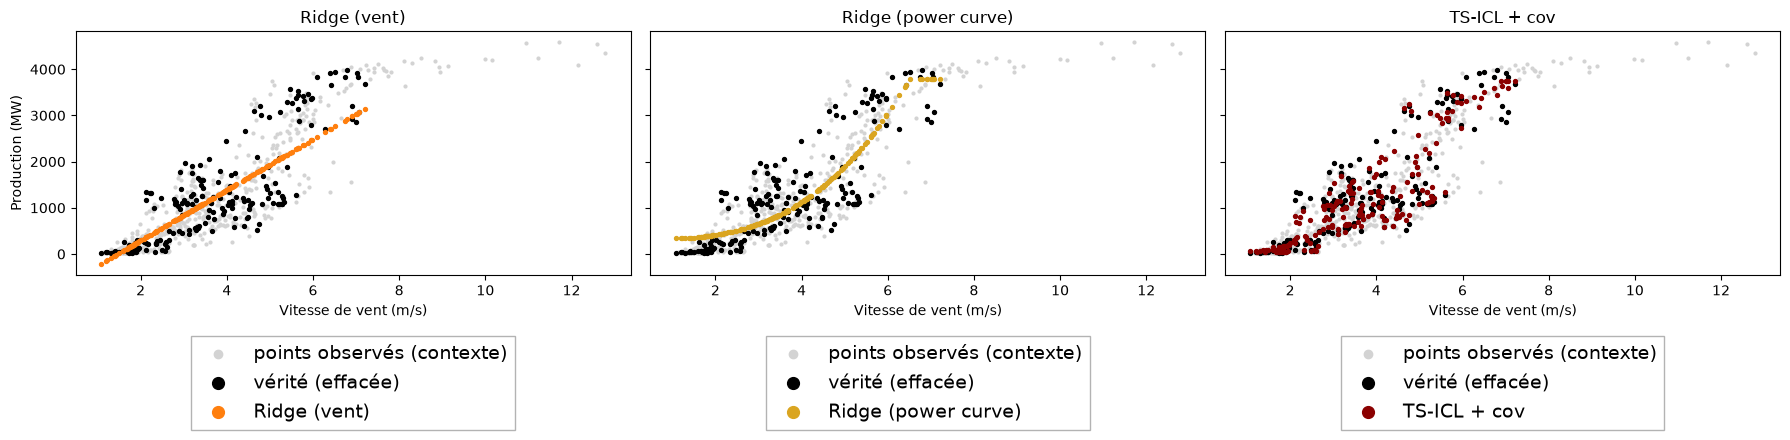

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharex=True, sharey=True)
for ax, name in zip(axes, ["Ridge (vent)", "Ridge (power curve)", "TS-ICL + cov"]):
    obs, hid = ~mask[WINDOW], mask[WINDOW]
    ax.scatter(ws[WINDOW, obs], y[WINDOW, obs], s=4, color="lightgray", label="points observés (contexte)")
    ax.scatter(ws[WINDOW, hid], y[WINDOW, hid], s=8, color="k", label="vérité (effacée)")
    ax.scatter(ws[WINDOW, hid], median(preds[name])[WINDOW, hid], s=8, color=COLORS[name], label=name)
    ax.set_xlabel("Vitesse de vent (m/s)")
    ax.set_title(name)
    legend_below(ax, markerscale=3)
axes[0].set_ylabel("Production (MW)")
plt.tight_layout()
plt.show()

- La **Ridge (vent)** est contrainte à une **droite** : elle surestime la production par vent faible (et peut même devenir négative) et sous-estime les forts vents.
- La **Ridge (power curve)** a la bonne forme (démarrage, montée, plateau) mais **ne fait pas mieux** que la Ridge linéaire : à vent régional donné, la production reste très dispersée (hétérogénéité spatiale du vent, direction, disponibilité des machines…). Une fonction du seul vent instantané ne peut pas expliquer cette dispersion.
- **TS-ICL** retrouve la **courbe de puissance non linéaire** à partir du seul contexte, et utilise en plus la dynamique temporelle de la production autour du trou.

### 4.4 Le chiffre qui compte : l'énergie non produite

Pour chacune des 38 × 8 = 304 journées écrêtées, on compare l'énergie reconstituée (MWh) à l'énergie réellement produite.

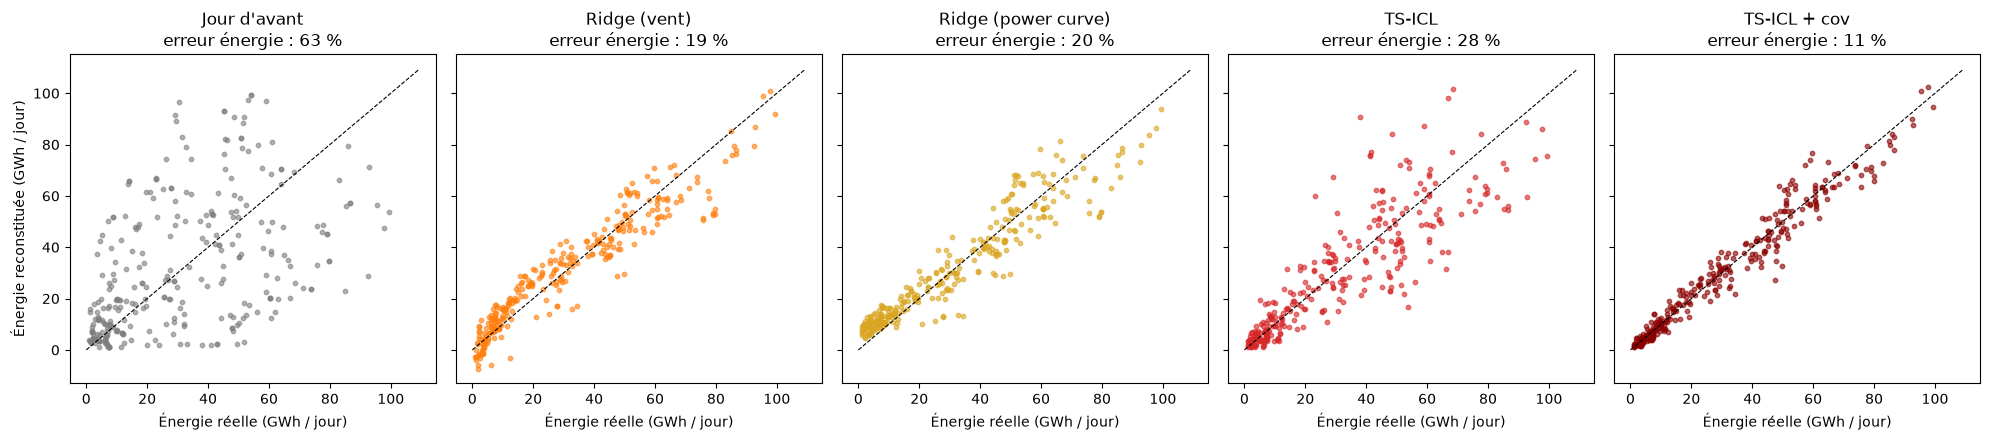

In [15]:
NAMES = ["Jour d'avant", "Ridge (vent)", "Ridge (power curve)", "TS-ICL", "TS-ICL + cov"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4.5), sharex=True, sharey=True)
lim = [0, E_true.max() * 1.1]
for ax, name in zip(axes, NAMES):
    E_hat = daily_energy(median(preds[name]))
    err   = 100 * np.abs(E_hat - E_true).sum() / E_true.sum()
    ax.scatter(E_true.ravel() / 1e3, E_hat.ravel() / 1e3, s=10, alpha=0.6, color=COLORS[name])
    ax.plot(np.array(lim) / 1e3, np.array(lim) / 1e3, color="k", lw=0.8, ls="--")
    ax.set_title(f"{name}\nerreur énergie : {err:.0f} %")
    ax.set_xlabel("Énergie réelle (GWh / jour)")
axes[0].set_ylabel("Énergie reconstituée (GWh / jour)")
plt.tight_layout()
plt.show()

### 4.5 Erreur par fenêtre

Le score global peut cacher des comportements hétérogènes. Distribution de la MAE normalisée sur les 38 fenêtres :

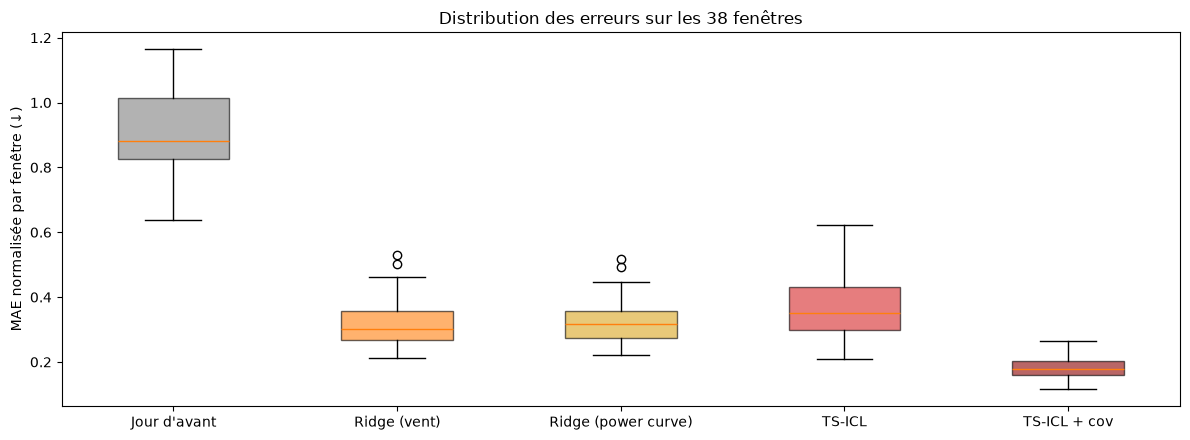

TS-ICL + cov bat la Ridge sur 38 fenêtres sur 38


In [16]:
fig, ax = plt.subplots(figsize=(12, 4.5))
bp = ax.boxplot([mae_per_window(n) for n in NAMES], tick_labels=NAMES, patch_artist=True, widths=0.5)
for patch, name in zip(bp["boxes"], NAMES):
    patch.set_facecolor(COLORS[name])
    patch.set_alpha(0.6)
ax.set_ylabel("MAE normalisée par fenêtre (↓)")
ax.set_title("Distribution des erreurs sur les 38 fenêtres")
plt.tight_layout()
plt.show()

wins = (mae_per_window("TS-ICL + cov") < mae_per_window("Ridge (vent)")).sum()
print(f"TS-ICL + cov bat la Ridge sur {wins} fenêtres sur {N}")

<a id="results"></a>

---
## 5. Bilan

In [17]:
results = scores(NAMES).sort_values("MAE (MW)")
results.style.highlight_min(subset=["MAE (MW)", "RMSE (MW)", "MAE norm.", "Erreur énergie (%)", "WQL"], color="#5727F5").format(precision=3)

,MAE (MW),RMSE (MW),MAE norm.,Erreur énergie (%),WQL,Couv. 80 %,Temps (s)
TS-ICL + cov,213.021,313.318,0.182,11.112,0.130,0.852,7.639
Ridge (vent),375.932,485.252,0.327,18.691,0.293,nan,0.047
Ridge (power curve),377.466,500.174,0.325,20.237,0.294,nan,2.908
TS-ICL,440.927,697.073,0.369,28.265,0.263,0.800,6.293
Jour d'avant,1066.289,1439.455,0.904,62.715,0.830,nan,nan


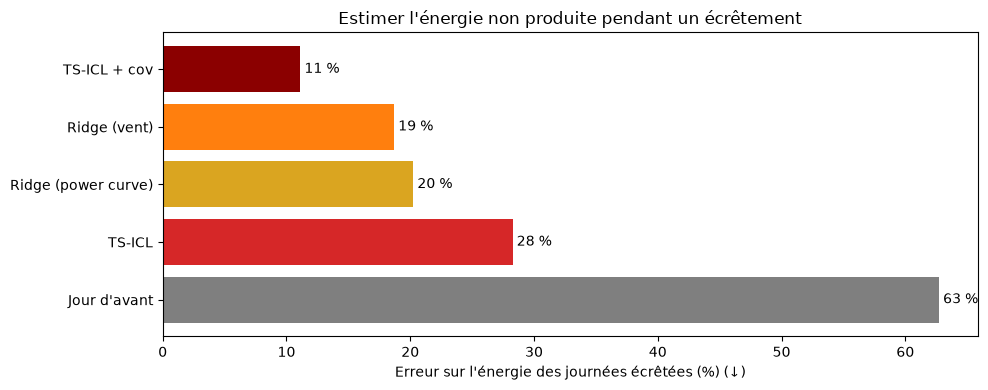

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
names = results.index[::-1]
bars  = ax.barh(names, results.loc[names, "Erreur énergie (%)"], color=[COLORS[n] for n in names])
ax.bar_label(bars, fmt="%.0f %%", padding=3)
ax.set_xlabel("Erreur sur l'énergie des journées écrêtées (%) (↓)")
ax.set_title("Estimer l'énergie non produite pendant un écrêtement")
plt.tight_layout()
plt.show()

#### À retenir

- **Zero-shot** : TS-ICL n'a jamais vu ces données ni été ajusté dessus, et reconstitue les journées écrêtées en un seul appel `impute`, directement sur la série trouée.
- **Sans covariable**, TS-ICL bat déjà largement la baseline *jour d'avant* : il exploite le contexte **des deux côtés** du trou.
- **Avec la vitesse de vent**, TS-ICL apprend en contexte la **courbe de puissance non linéaire** et la dynamique de la production : il divise par ~1,8 l'erreur horaire d'une Ridge ajustée sur la même covariable (et la bat sur les 38 fenêtres), et ramène l'erreur sur l'énergie non produite de ~19 % à ~11 %.
- Ajouter de la physique « à la main » ne suffit pas : même une **courbe de puissance** ajustée sur chaque fenêtre ne fait pas mieux que la Ridge linéaire. TS-ICL combine la relation vent → production, apprise en contexte, avec la **dynamique temporelle** de la production autour du trou, ce qu'aucune fonction du vent instantané ne peut faire.
- TS-ICL est **probabiliste** : l'intervalle 80 % est bien calibré (couverture de 80 à 85 %), ce qui permet d'accompagner l'estimation d'énergie d'une incertitude.